# Input formats

Earthkit-meteo supports the following input types:

- arrays (Numpy, Torch and CuPy)
- XArray dataarrays
- earthkit-data fieldlists

Almost all the methods support at least the array input, but many of them support all the 3 formats.

The earthkit-meteo API is split into two layers:

- Low-level implementations are in the ``array``, ``xarray`` and ``fieldlist`` submodules.
- High-level functions are in this module and dispatch to backend implementations (when available) based on input type.

In [5]:
import earthkit.data as ekd
import earthkit.plots as ekp

from earthkit.meteo import wind

## Wind speed

First, we generate the input data for array, Xarray and fieldlist.

In [6]:
# get Xarray dataset
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()

# get GRIB fieldlist
fl = ekd.from_source("sample", "era5_tquv_pl_subarea.grib").to_fieldlist()

# get input numpy arrays
u_arr = ds.u.values
v_arr = ds.v.values

era5_tquv_pl_subarea.nc:   0%|          | 0.00/14.6M [00:00<?, ?B/s]

era5_tquv_pl_subarea.grib:   0%|          | 0.00/16.6M [00:00<?, ?B/s]

### Using the high level interface

In [7]:
# import the high level wind module

When Earthkit-meteo is still work in progress and the metadata is not yet set in the resulting DataArray. We will set it manually.

In [9]:
# compute with Xarray
sp = wind.speed(ds.u, ds.v)

# set the metadata manually
sp.attrs["standard_name"] = "wind_speed"
sp.attrs["long_name"] = "wind_speed"
sp = sp.rename("ws")
sp

<xarray.DataArray 'ws' (valid_time: 4, pressure_level: 3, latitude: 301,
                        longitude: 601)> Size: 9MB
array([[[[7.21209857e-04, 7.21209857e-04, 7.21209857e-04, ...,
          7.21209857e-04, 7.21209857e-04, 7.21209857e-04],
         [9.15587044e+00, 9.15572071e+00, 9.15571594e+00, ...,
          9.67847347e+00, 9.67668724e+00, 9.67551231e+00],
         [8.77466106e+00, 8.77321625e+00, 8.77142429e+00, ...,
          9.91900063e+00, 9.91710377e+00, 9.91543484e+00],
         ...,
         [1.12219691e+00, 1.00199103e+00, 8.06946635e-01, ...,
          9.93535876e-01, 4.55393404e-01, 6.65705085e-01],
         [4.73718941e-01, 4.93476927e-01, 5.56098044e-01, ...,
          5.67884982e-01, 7.18522072e-01, 4.60717976e-01],
         [1.05491556e-01, 3.18013817e-01, 4.84191030e-01, ...,
          9.93801832e-01, 6.87026620e-01, 4.87377763e-01]],

        [[1.04129361e-03, 1.04129361e-03, 1.04129361e-03, ...,
          1.04129361e-03, 1.04129361e-03, 1.04129361e-03],
         [8.28795815e+00, 8.29496670e+00, 8.30037975e+00, ...,
          8.25793839e+00, 8.25712204e+00, 8.25645351e+00],
         [8.83082581e+00, 8.84640408e+00, 8.86025906e+00, ...,
          8.32423401e+00, 8.32343578e+00, 8.32278347e+00],
...
          1.70103025e+00, 1.26007354e+00, 1.77098072e+00],
         [2.65315723e+00, 2.73314214e+00, 2.64034247e+00, ...,
          2.76825452e+00, 2.20397377e+00, 2.17171168e+00],
         [2.73072147e+00, 2.88751960e+00, 2.87780690e+00, ...,
          2.61288738e+00, 2.68276882e+00, 2.50446677e+00]],

        [[6.33009884e-04, 6.33009884e-04, 6.33009884e-04, ...,
          6.33009884e-04, 6.33009884e-04, 6.33009884e-04],
         [7.87639523e+00, 7.87548780e+00, 7.87472439e+00, ...,
          7.88470078e+00, 7.88728619e+00, 7.89145756e+00],
         [7.69088745e+00, 7.68987322e+00, 7.68869591e+00, ...,
          7.31118202e+00, 7.31721783e+00, 7.32209921e+00],
         ...,
         [3.76584339e+00, 4.03104496e+00, 4.31973362e+00, ...,
          9.29071903e+00, 7.57689333e+00, 6.01164341e+00],
         [4.17330790e+00, 4.29592800e+00, 4.42056227e+00, ...,
          8.29728794e+00, 6.92111635e+00, 5.99423361e+00],
         [4.42543697e+00, 4.44226933e+00, 4.52274704e+00, ...,
          6.44288826e+00, 6.02955246e+00, 6.10808563e+00]]]],
      shape=(4, 3, 301, 601), dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                wind_speed
    units:                                    m s**-1
    standard_name:                            wind_speed

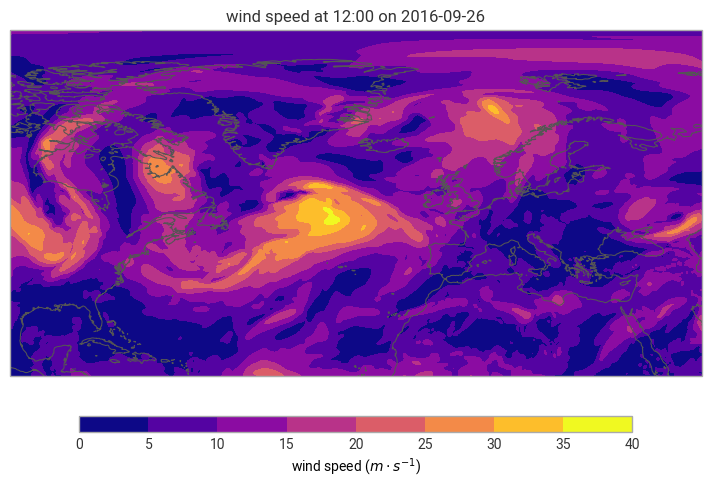

In [11]:
ekp.quickplot(sp.sel(pressure_level=700, valid_time="2016-09-26T12"))

In [13]:
# compute fieldlist
u = fl.sel({"parameter.variable": "u"})
v = fl.sel({"parameter.variable": "v"})
sp = wind.speed(u, v)
sp.ls()

TypeError: attribute name must be string, not 'function'

### Xarray

In [ ]:
# compute array
sp_arr = wind.speed(u_arr, v_arr)

In [ ]:
# get Xarray dataset
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()

# get GRIB fieldlist
fl = ekd.from_source("sample", "era5_tquv_pl_subarea.grib").to_fieldlist()

# get input numpy arrays
u = ds["u"].values
v = ds["v"].values

Next, we compute the wind speed with [earthkit.meteo.wind.speed](https://earthkit-meteo.readthedocs.io/en/latest/autoapi/earthkit/meteo/wind/xarray/speed.html#earthkit.meteo.wind.xarray.wind). We pass DataArrays to this method.

In [ ]:
sp = wind.speed(ds.u, ds.v)
sp

Earthkit-meteo is still work in progress and the metadata is not yet set in the resulting DataArray. We will set it manually.

In [ ]:
sp.attrs["standard_name"] = "wind_speed"
sp.attrs["long_name"] = "wind_speed"
sp = sp.rename("ws")

Finally, we plot some of the data for visual checking.

In [ ]:
# select one level and step and plot wind field overlaid with the computed speed
u = ds.u.sel(pressure_level=700, valid_time="2016-09-26T12")
v = ds.v.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1 = sp.sel(pressure_level=700, valid_time="2016-09-26T12")

chart = ekp.Map()
chart.contourf(sp1, units="m s-1", colors="Greens", levels=list(range(5, 45, 5)), alpha=1)

chart.quiver(u=u, v=v, headwidth=2.5, width=0.002)

# Add map features
chart.coastlines()
chart.land()
chart.gridlines()
chart.legend()

# Show the plot
chart.show()

### Fieldlist

Fetch the same input data but this time in GRIB format and load it into a fieldlist.

In [ ]:
fl = ekd.from_source("sample", "era5_tquv_pl_subarea.grib").to_fieldlist()
fl.head()

Fieldlist based computations are experimental and limited to wind. The methods have to be imported from a dedicated submodule.

In [ ]:
from earthkit.meteo.wind import fieldlist as wind_fl

To compute the speed we need to extract the u and v components. The computations do not check if the u and v fields are aligned in terms of metadata, the user must ensure this. Luckily, our input data is properly sorted so we do not need to deal with it.

In [ ]:
u = fl.sel({"parameter.variable": "u"})
v = fl.sel({"parameter.variable": "v"})

When the speed is computed the metadata is correctly set in the results.

In [ ]:
sp = wind_fl.speed(u, v)
sp.head()